In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from kan import KAN
#set seed
torch.manual_seed(42)
np.random.seed(42)
#device availability
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on device:{device}")

running on device:cpu


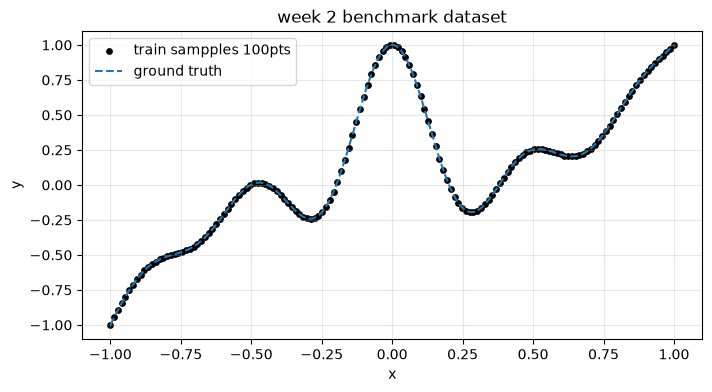

In [17]:
#bessel spatial
# cell replacement: generate bessel-like wave mode dataset
x_train = torch.linspace(-1, 1, 150).unsqueeze(1)
y_train = torch.sin(5 * np.pi * x_train) / (5 * np.pi * x_train + 1e-5) + x_train**3

x_test = torch.linspace(-1, 1, 400).unsqueeze(1)
y_test = torch.sin(5 * np.pi * x_test) / (5 * np.pi * x_test + 1e-5) + x_test**3

x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)
plt.figure(figsize=(8,4))
plt.scatter(x_train.cpu(),y_train.cpu(), color="black", label="train sampples 100pts",s=15)
plt.plot(x_test.cpu(),y_test.cpu(),color="tab:blue",linestyle="--",label="ground truth")
plt.xlabel("x")
plt.ylabel("y")
plt.title("week 2 benchmark dataset")
plt.legend()
plt.grid(True, alpha =0.3)
plt.show()



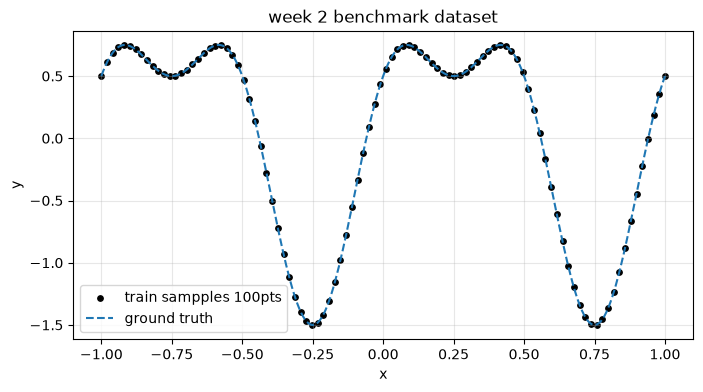

In [9]:
#1d sample points
x_train = torch.linspace(-1,1,100).unsqueeze(1)
y_train = torch.sin(2*np.pi*x_train)+0.5*torch.cos(4*np.pi*x_train)
x_test= torch.linspace(-1,1,300).unsqueeze(1)
y_test=torch.sin(2*np.pi*x_test)+0.5*torch.cos(4*np.pi*x_test)
#move to device
x_train, y_train=x_train.to(device), y_train.to(device)
x_test, y_test=x_test.to(device), y_test.to(device)
plt.figure(figsize=(8,4))
plt.scatter(x_train.cpu(),y_train.cpu(), color="black", label="train sampples 100pts",s=15)
plt.plot(x_test.cpu(),y_test.cpu(),color="tab:blue",linestyle="--",label="ground truth")
plt.xlabel("x")
plt.ylabel("y")
plt.title("week 2 benchmark dataset")
plt.legend()
plt.grid(True, alpha =0.3)
plt.show()



In [18]:
#mlp
class BaselineMLP(nn.Module):
    def __init__(self, in_dim=1,hidden_dim=64,out_dim=1):
        super(BaselineMLP,self).__init__()
        self.net=nn.Sequential(
        nn.Linear(in_dim,hidden_dim),
        nn.SiLU(),
        nn.Linear(hidden_dim,hidden_dim),
        nn.SiLU(),
        nn.Linear(hidden_dim,out_dim)
        )
    def forward(self,x):
        return self.net(x)
mlp_model=BaselineMLP().to(device)
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(mlp_model.parameters(),lr=1e-2)
#training loop
mlp_losses=[]
epochs=1000
for epoch in range(epochs):
    optimizer.zero_grad()
    preds=mlp_model(x_train)
    loss=criterion(preds, y_train)
    loss.backward()
    optimizer.step()
    mlp_losses.append(loss.item())
print(f"MLP final training loss:{mlp_losses[-1]:.6f}")


MLP final training loss:0.000840


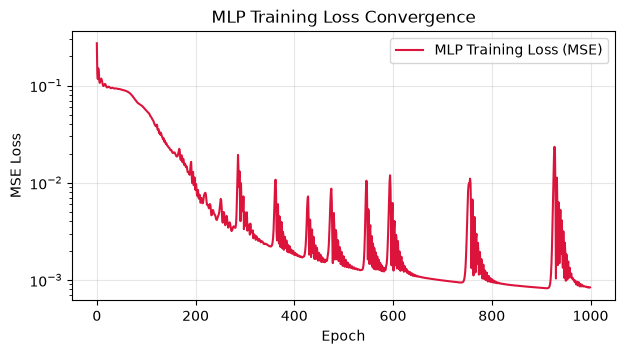

In [19]:
# ==========================================
# 1. Training Loss Convergence Curve
# ==========================================
plt.figure(figsize=(7, 3.5))
plt.plot(mlp_losses, color="crimson", label="MLP Training Loss (MSE)")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Training Loss Convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
#KAN
#2layer kan 1 input 5hidden 1output
kan_dataset={
    'train_input':x_train,
    'train_label':y_train,
    'test_input':x_test,
    'test_label':y_test
}
kan_model=KAN(width=[1,5,1],grid=5,k=3,device=device)
#train kan using l bfgs
results=kan_model.fit(kan_dataset,opt="LBFGS",steps=50,lamb=0.001)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.68e-02 | test_loss: 2.67e-02 | reg: 7.68e+00 | : 100%|█| 50/50 [00:07<00:00,  6.77it

saving model version 0.1


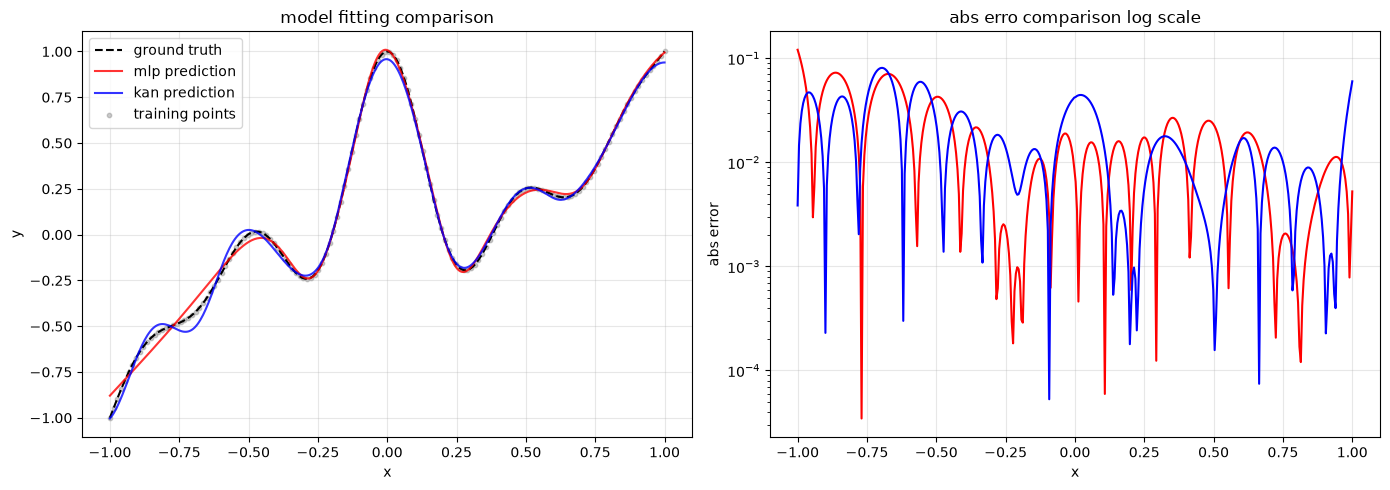

In [21]:
#test grid
mlp_model.eval()
with torch.no_grad():
    y_mlp_pred=mlp_model(x_test).cpu().numpy()
    y_kan_pred=kan_model(x_test).detach().cpu().numpy()
x_eval=x_test.cpu().numpy()
y_true=y_test.cpu().numpy()
fig,axes=plt.subplots(1,2,figsize=(14,5))
#visaul fit
axes[0].plot(x_eval,y_true,"k--",label="ground truth",linewidth=1.5)
axes[0].plot(x_eval,y_mlp_pred,"r-",label="mlp prediction",alpha=0.8)
axes[0].plot(x_eval,y_kan_pred,"b-",label="kan prediction",alpha=0.8)
axes[0].scatter(x_train.cpu().numpy(),y_train.cpu().numpy(),color="gray",alpha=0.4,s=10,label="training points")
axes[0].set_title("model fitting comparison")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True,alpha=0.3)
#abs error comparison
axes[1].plot(x_eval, np.abs(y_true - y_mlp_pred), "r-", label=f"mlp test error (mse: {np.mean((y_true - y_mlp_pred)**2):.4e})")
axes[1].plot(x_eval, np.abs(y_true - y_kan_pred), "b-", label=f"kan test error (mse: {np.mean((y_true - y_kan_pred)**2):.4e})")
axes[1].set_yscale("log")
axes[1].set_title("abs erro comparison log scale")
axes[1].set_xlabel("x")
axes[1].set_ylabel("abs error")
axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.show()
             

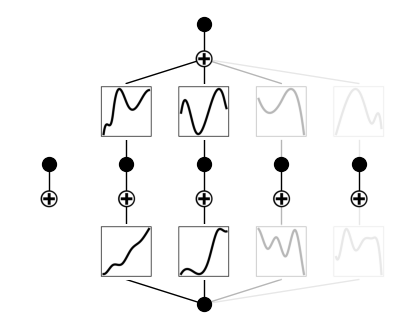

In [22]:
#visualize learned spline activation fucntions across kan edges
kan_model.plot(beta=100)

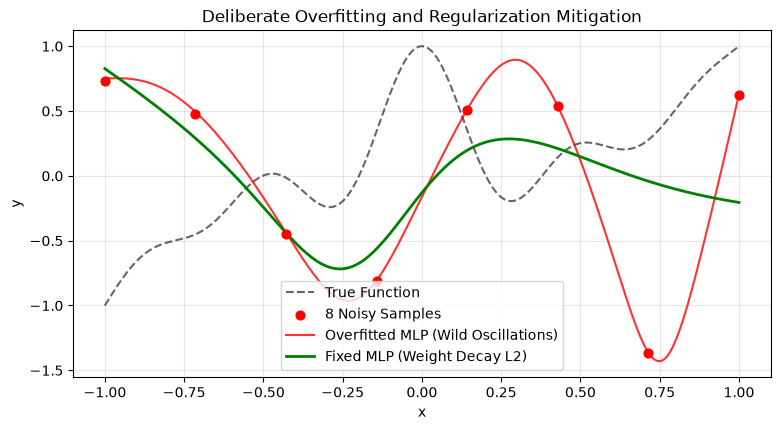

In [23]:
# =========================================================
# 2. Overfitting vs. Regularization Demonstration (Week 2)
# =========================================================

# Subsample only 8 noisy training points to force overfitting
x_small = torch.linspace(-1, 1, 8).unsqueeze(1).to(device)
y_small = (torch.sin(2*np.pi*x_small) + 0.5*torch.cos(4*np.pi*x_small) + 0.15*torch.randn_like(x_small)).to(device)

# --- Model A: Overfitted Network (High capacity, no regularization) ---
overfit_model = BaselineMLP(hidden_dim=128).to(device)
opt_overfit = torch.optim.Adam(overfit_model.parameters(), lr=0.01)

for _ in range(2500):
    opt_overfit.zero_grad()
    loss = criterion(overfit_model(x_small), y_small)
    loss.backward()
    opt_overfit.step()

# --- Model B: Fixed / Regularized Network (Weight decay L2 regularization) ---
fixed_model = BaselineMLP(hidden_dim=128).to(device)
opt_fixed = torch.optim.Adam(fixed_model.parameters(), lr=0.01, weight_decay=1e-2)

for _ in range(2500):
    opt_fixed.zero_grad()
    loss = criterion(fixed_model(x_small), y_small)
    loss.backward()
    opt_fixed.step()

# Evaluate both on dense test grid
overfit_model.eval()
fixed_model.eval()
with torch.no_grad():
    y_pred_overfit = overfit_model(x_test).cpu().numpy()
    y_pred_fixed = fixed_model(x_test).cpu().numpy()

# Plot the comparison
plt.figure(figsize=(9, 4.5))
plt.plot(x_eval, y_true, "k--", label="True Function", alpha=0.6)
plt.scatter(x_small.cpu().numpy(), y_small.cpu().numpy(), color="red", s=40, zorder=5, label="8 Noisy Samples")
plt.plot(x_eval, y_pred_overfit, "r-", label="Overfitted MLP (Wild Oscillations)", alpha=0.8)
plt.plot(x_eval, y_pred_fixed, "g-", label="Fixed MLP (Weight Decay L2)", linewidth=2)
plt.title("Deliberate Overfitting and Regularization Mitigation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()